In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [25]:
reviews = pd.read_csv('p5_order_reviews_dataset.csv')
orders = pd.read_csv('p5_orders_dataset.csv')
products = pd.read_csv('p5_products_dataset.csv')
items = pd.read_csv('p5_order_items_dataset.csv')

products.head()  # Para conferir se carregou

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [26]:
# 2. Merge das tabelas
df = pd.merge(reviews, orders, on="order_id", how="inner")


df_items = pd.merge(items, products, on="product_id", how="left")

df_full = pd.merge(df, df_items, on="order_id", how="left")


df_full.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,...,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,...,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,...,79.79,8.30,informatica_acessorios,47.0,493.0,1.0,245.0,19.0,14.0,14.0
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,...,149.00,45.12,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,...,179.99,42.85,ferramentas_jardim,33.0,2188.0,2.0,7650.0,20.0,20.0,20.0


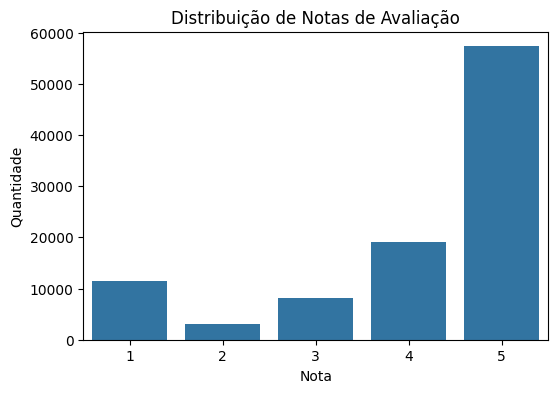

Percentual de cada nota:
 review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64


In [27]:

# 3. Distribuição das notas
plt.figure(figsize=(6,4))
sns.countplot(x="review_score", data=df)
plt.title("Distribuição de Notas de Avaliação")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

# Percentual de cada nota
dist = df["review_score"].value_counts(normalize=True).sort_index() * 100
print("Percentual de cada nota:\n", dist)

C:\Users\Asus\AppData\Local\Temp\ipykernel_10840\2787012791.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


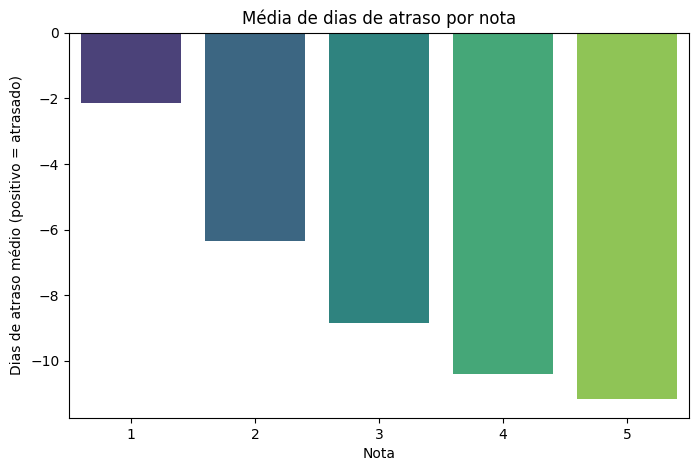

In [28]:

# 4. Analisando tempo de entrega 
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

df["delivery_delay"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

df_filtered = df[df["delivery_delay"].between(-20, 40)]

mean_delay = df_filtered.groupby("review_score")["delivery_delay"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    x="review_score",
    y="delivery_delay",
    data=mean_delay,
    palette="viridis"
)
plt.title("Média de dias de atraso por nota")
plt.xlabel("Nota")
plt.ylabel("Dias de atraso médio (positivo = atrasado)")
plt.show()

In [29]:

# 5. Categorias com mais notas baixas (1 a 3)
cat_low = df_full[df_full["review_score"] <= 3].groupby("product_category_name")["review_score"].count().sort_values(ascending=False)
print("Top 10 categorias com mais avaliações baixas:\n", cat_low.head(10))

Top 10 categorias com mais avaliações baixas:
 product_category_name
cama_mesa_banho           3221
moveis_decoracao          2375
informatica_acessorios    2108
beleza_saude              2079
esporte_lazer             1900
utilidades_domesticas     1680
relogios_presentes        1499
telefonia                 1221
ferramentas_jardim        1042
automotivo                 965
Name: review_score, dtype: int64


In [30]:
df_full["order_delivered_customer_date"] = pd.to_datetime(df_full["order_delivered_customer_date"])
df_full["order_estimated_delivery_date"] = pd.to_datetime(df_full["order_estimated_delivery_date"])

df_full["delivery_delay"] = (
    df_full["order_delivered_customer_date"] - df_full["order_estimated_delivery_date"]
).dt.days

In [31]:
print(df_model.isnull().sum())

delivery_delay    0
neg_review        0
dtype: int64


In [33]:

#Prever se uma avaliação será negativa ou não
#(usando o atraso na entrega como base)
df_full["neg_review"] = (df_full["review_score"] <= 3).astype(int)


df_model = df_full[["delivery_delay", "neg_review"]].copy()


df_model["delivery_delay"] = pd.to_numeric(df_model["delivery_delay"], errors="coerce")


df_model["delivery_delay"] = df_model["delivery_delay"].fillna(0)

print(df_model.isnull().sum())

# Separar dados
X = df_model[["delivery_delay"]]
y = df_model["neg_review"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)  # aumentei pra evitar outro erro comum
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Relatório de Classificação:\n", classification_report(y_test, y_pred))

delivery_delay    0
neg_review        0
dtype: int64
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87     25531
           1       0.88      0.10      0.17      8409

    accuracy                           0.77     33940
   macro avg       0.82      0.55      0.52     33940
weighted avg       0.80      0.77      0.70     33940



In [34]:
# % das avaliações que são negativas.
df["negative_review"] = df["review_score"].apply(lambda x: 1 if x <= 2 else 0)

# Conferir proporção
print(df["negative_review"].value_counts(normalize=True))

negative_review
0    0.85311
1    0.14689
Name: proportion, dtype: float64
